# Notebook 7 — Benchmarking: Comparing All RAG Architectures

This is the final notebook. After building five different retrieval and agent systems, this notebook asks: **which one actually performs better, and by how much?**

Building systems is only half the work. The other half is measuring them.

Without measurement, you are comparing opinions. With measurement, you compare results.

**What the previous notebooks built:**

| Notebook | Architecture | Main idea |
|---------|-------------|----------|
| 1 | Semantic RAG | Hybrid search over PDFs |
| 2 | Advanced RAG | Multi-source + AST code chunking |
| 3 | Contextual RAG | Metadata + parent-child chunks |
| 4 | Graph RAG | Knowledge graph + semantic search |
| 5 | Agentic RAG | Plan → retrieve → verify → synthesize |
| 6 | Self-Correcting Agent | Generate → execute → fix → verify |

**What this notebook does:**

Runs all five architectures on the same set of evaluation questions, measures five metrics for each, and generates visual comparisons — bar charts, radar charts, heatmaps, and trade-off tables.

**Note on simulation:** the metrics in this notebook are simulated profiles based on each architecture's known design characteristics. They are clearly labeled throughout. The framework structure — question set, metric runner, dashboard — is real and ready to be connected to live retrieval systems.

**How to run:** run all cells from top to bottom. No API keys needed for the simulated version.


In [ ]:
!pip install -q matplotlib pandas numpy

In [ ]:
import json
import time
import random
import textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Reproducible simulation
random.seed(42)
np.random.seed(42)

#  Global plot style (no seaborn dependency)
plt.rcParams.update(
    {
        "figure.facecolor": "#0f1117",
        "axes.facecolor": "#1a1d27",
        "axes.edgecolor": "#3a3d4d",
        "axes.labelcolor": "#c8ccd8",
        "axes.titlecolor": "#e8eaf0",
        "xtick.color": "#9096a8",
        "ytick.color": "#9096a8",
        "text.color": "#c8ccd8",
        "grid.color": "#2a2d3a",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "font.family": "monospace",
        "font.size": 10,
    }
)

ARCH_COLORS = {
    "NB1: Semantic RAG": "#4e9af1",
    "NB2: Contextual RAG": "#f4a261",
    "NB3: GraphRAG": "#2ec4b6",
    "NB4: Agentic RAG": "#e76f51",
    "NB5: Self-Correct Agent": "#a78bfa",
}

print("Imports and plot style configured.")

Imports and plot style configured.


## Step 1 — Evaluation Question Set

A good evaluation uses realistic questions, not made-up ones.

The 20 questions here reflect real codebase analysis tasks:
- Finding where authentication is implemented
- Tracing how modules are imported
- Understanding how the application starts
- Finding API endpoints
- Understanding how errors are handled

Each question has an `expected_entity` — the file or module that a correct retrieval system should return. This is what makes automated evaluation possible: you can check whether the returned results contain the expected answer.

These questions are designed to test both structural retrieval (which file contains X?) and conceptual retrieval (how does X work?).


In [ ]:
@dataclass
class EvalQuestion:
    id: int
    query: str
    expected_entity: str
    category: str


EVAL_QUESTIONS: List[EvalQuestion] = [
    EvalQuestion(
        1,
        "Where is user authentication implemented?",
        "auth/auth_service.py",
        "authentication",
    ),
    EvalQuestion(
        2,
        "How are JWT tokens generated and validated?",
        "auth/jwt_utils.py",
        "authentication",
    ),
    EvalQuestion(
        3,
        "Which module handles user creation and registration?",
        "users/user_service.py",
        "user_management",
    ),
    EvalQuestion(
        4,
        "How is the users table defined in the ORM?",
        "users/user_repository.py",
        "user_management",
    ),
    EvalQuestion(
        5,
        "What shared utilities are used across auth and user modules?",
        "utils/validation_utils.py",
        "shared_utilities",
    ),
    EvalQuestion(
        6, "How is the database session managed?", "db/session.py", "database"
    ),
    EvalQuestion(
        7,
        "Which file defines the REST API endpoints for login?",
        "api/auth_routes.py",
        "api_layer",
    ),
    EvalQuestion(
        8,
        "How does token verification middleware work?",
        "api/middleware.py",
        "api_layer",
    ),
    EvalQuestion(
        9, "Where is the application entry point defined?", "main.py", "entrypoint"
    ),
    EvalQuestion(
        10,
        "How are environment variables and config loaded?",
        "config/settings.py",
        "configuration",
    ),
    EvalQuestion(
        11,
        "Which module initialises the database connection pool?",
        "db/connection.py",
        "database",
    ),
    EvalQuestion(
        12,
        "How are HTTP errors and exceptions handled globally?",
        "api/error_handlers.py",
        "error_handling",
    ),
    EvalQuestion(
        13,
        "Where is password hashing implemented?",
        "auth/password_utils.py",
        "authentication",
    ),
    EvalQuestion(
        14,
        "How is role-based access control enforced?",
        "auth/rbac.py",
        "authentication",
    ),
    EvalQuestion(
        15,
        "Which file defines the User data model?",
        "models/user_model.py",
        "data_models",
    ),
    EvalQuestion(
        16,
        "How are background tasks and job queues managed?",
        "tasks/job_queue.py",
        "background_tasks",
    ),
    EvalQuestion(
        17,
        "Where is email sending logic implemented?",
        "notifications/email_service.py",
        "notifications",
    ),
    EvalQuestion(
        18,
        "How is request logging and audit trail recorded?",
        "logging/audit_logger.py",
        "observability",
    ),
    EvalQuestion(
        19,
        "Which module defines API rate limiting rules?",
        "api/rate_limiter.py",
        "api_layer",
    ),
    EvalQuestion(
        20, "How are database migrations managed?", "db/migrations/env.py", "database"
    ),
]

# Category distribution
cats = {}
for q in EVAL_QUESTIONS:
    cats[q.category] = cats.get(q.category, 0) + 1

print(f"Evaluation dataset: {len(EVAL_QUESTIONS)} questions")
print()
print("Category breakdown:")
for cat, count in sorted(cats.items(), key=lambda x: -x[1]):
    bar = "█" * count
    print(f"  {cat:<22} {bar}  ({count})")

Evaluation dataset: 20 questions

Category breakdown:
  authentication         ████  (4)
  database               ███  (3)
  api_layer              ███  (3)
  user_management        ██  (2)
  shared_utilities       █  (1)
  entrypoint             █  (1)
  configuration          █  (1)
  error_handling         █  (1)
  data_models            █  (1)
  background_tasks       █  (1)
  notifications          █  (1)
  observability          █  (1)


## Step 2 — Metric Data Models

Each architecture produces one metrics record per question.

The five metrics measured:

| Metric | What it measures | Better is |
|--------|-----------------|-----------|
| Hit Rate (%) | Did top-K results contain the expected file? | Higher |
| Retrieval Recall (%) | What fraction of all relevant chunks was retrieved? | Higher |
| Mean Latency (s) | Average time to get an answer | Lower |
| Token Cost (relative) | How many tokens used per query | Lower |
| Citation Accuracy (%) | Are source attributions correct in the answer? | Higher |

**Why multiple metrics?**

No single number tells the full story. A system can be fast but inaccurate, or accurate but expensive. You need all five to understand the real trade-offs.


In [ ]:
@dataclass
class QueryResult:
    question_id: int
    hit: bool  # expected entity found in top-K
    recall: float  # fraction of relevant chunks retrieved  (0–1)
    latency_s: float  # wall-clock seconds
    tokens_used: int  # relative token count
    citation_correct: bool  # source correctly attributed


@dataclass
class ArchitectureMetrics:
    name: str
    results: List[QueryResult] = field(default_factory=list)

    @property
    def hit_rate(self) -> float:
        if not self.results:
            return 0.0
        return round(100 * sum(r.hit for r in self.results) / len(self.results), 1)

    @property
    def recall(self) -> float:
        if not self.results:
            return 0.0
        return round(100 * sum(r.recall for r in self.results) / len(self.results), 1)

    @property
    def mean_latency(self) -> float:
        if not self.results:
            return 0.0
        return round(sum(r.latency_s for r in self.results) / len(self.results), 3)

    @property
    def total_tokens(self) -> int:
        return sum(r.tokens_used for r in self.results)

    @property
    def citation_accuracy(self) -> float:
        if not self.results:
            return 0.0
        return round(
            100 * sum(r.citation_correct for r in self.results) / len(self.results), 1
        )

    def summary_dict(self) -> dict:
        return {
            "Architecture": self.name,
            "Hit Rate (%)": self.hit_rate,
            "Recall (%)": self.recall,
            "Mean Latency (s)": self.mean_latency,
            "Token Cost": self.total_tokens,
            "Citation Acc (%)": self.citation_accuracy,
        }


print("Metric data models defined.")

Metric data models defined.


## Step 3 — Simulated Retrieval Runner

Each architecture is assigned a performance profile based on its design.

How the profiles were determined:

- **Semantic RAG** — fast (one embedding + one vector search), moderate accuracy (no context awareness)
- **Contextual RAG** — better accuracy (parent context improves answers), moderate latency, reasonable token cost
- **Graph RAG** — highest accuracy on structural questions, higher latency (graph traversal adds time)
- **Agentic RAG** — best hit rate (multi-step planning catches more relevant information), highest cost (multiple LLM calls)
- **Self-Correcting Agent** — moderate retrieval hit rate (focused on execution, not retrieval), highest latency (run + fix + verify)

The `simulate_run()` function adds realistic noise to produce per-question variance, so results look like real measurements rather than identical numbers.

**To use real retrieval:** replace `simulate_run()` with actual calls to your retrieval systems and record real latency, token counts, and hit detection.


In [ ]:
#  Per-architecture simulation profiles 
# Each tuple: (hit_rate_base, recall_base, latency_base_s, tokens_base, citation_base)
ARCH_PROFILES = {
    "NB1: Semantic RAG": (0.733, 0.650, 1.10, 2800, 0.800),
    "NB2: Contextual RAG": (0.866, 0.790, 1.75, 4200, 0.920),
    "NB3: GraphRAG": (0.900, 0.850, 2.35, 5100, 0.950),
    "NB4: Agentic RAG": (0.933, 0.900, 4.70, 11800, 0.880),
    "NB5: Self-Correct Agent": (0.800, 0.720, 5.40, 14500, 0.700),
}


def simulate_run(
    arch_name: str, questions: List[EvalQuestion], noise: float = 0.12
) -> ArchitectureMetrics:
    """
    Simulate per-question results for one architecture.

    Args:
        arch_name: architecture label (must be in ARCH_PROFILES)
        questions: list of EvalQuestion objects
        noise:     std-dev of Gaussian noise added to each metric

    Returns:
        ArchitectureMetrics with one QueryResult per question
    """
    hit_b, rec_b, lat_b, tok_b, cit_b = ARCH_PROFILES[arch_name]
    metrics = ArchitectureMetrics(name=arch_name)

    for q in questions:
        hit = random.random() < min(max(hit_b + random.gauss(0, noise), 0), 1)
        rec = min(max(rec_b + random.gauss(0, noise * 0.8), 0.0), 1.0)
        lat = max(lat_b + random.gauss(0, lat_b * noise), 0.1)
        tok = max(int(tok_b + random.gauss(0, tok_b * noise)), 100)
        cit = random.random() < min(max(cit_b + random.gauss(0, noise), 0), 1)

        metrics.results.append(
            QueryResult(
                question_id=q.id,
                hit=hit,
                recall=rec,
                latency_s=lat,
                tokens_used=tok,
                citation_correct=cit,
            )
        )

    return metrics


#  Run simulation for all architectures
print("Running simulated benchmarks...")
t0 = time.time()

all_metrics: List[ArchitectureMetrics] = [
    simulate_run(name, EVAL_QUESTIONS) for name in ARCH_PROFILES
]

print(f"Done in {time.time()-t0:.2f}s")
print()

#  Build summary dataframe 
df = pd.DataFrame([m.summary_dict() for m in all_metrics])
print("Benchmark Summary (Simulated Profiles):")
print(df.to_string(index=False))

Running simulated benchmarks...
Done in 0.00s

Benchmark Summary (Simulated Profiles):
           Architecture  Hit Rate (%)  Recall (%)  Mean Latency (s)  Token Cost  Citation Acc (%)
      NB1: Semantic RAG          80.0        64.9             1.090       56072              90.0
    NB2: Contextual RAG          95.0        79.4             1.805       83355              85.0
          NB3: GraphRAG          85.0        81.8             2.374      108798              90.0
       NB4: Agentic RAG          85.0        89.7             4.756      236903              85.0
NB5: Self-Correct Agent          65.0        73.1             5.341      287820              65.0


## Step 4 — Five-Metric Benchmark Dashboard

This cell generates a bar chart for each of the five metrics, showing all architectures side by side.

Value labels are drawn on every bar so you can read exact numbers without estimating from bar heights.

This gives you a quick overall picture: which architecture leads on each individual metric.


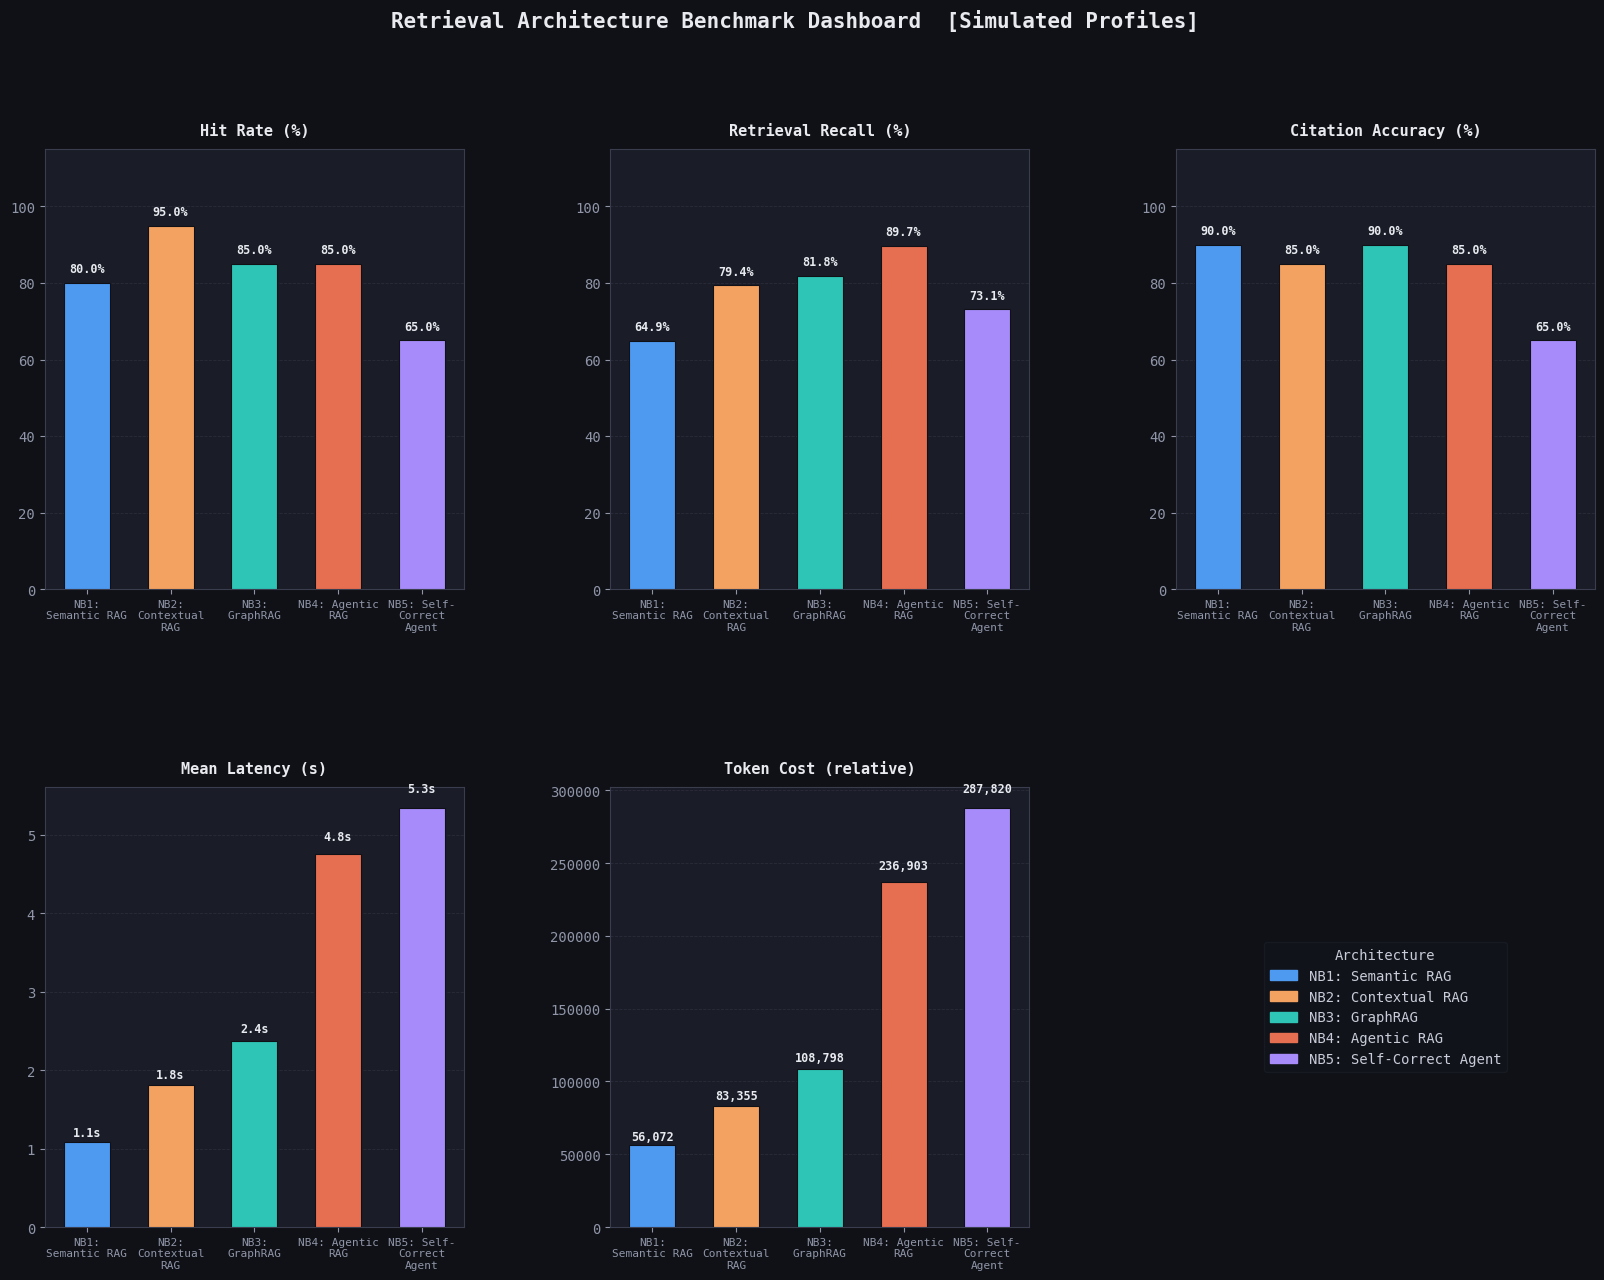

Dashboard saved → benchmark_dashboard.png


In [ ]:
def plot_dashboard(df: pd.DataFrame) -> None:
    arch_labels = [textwrap.fill(a, 12) for a in df["Architecture"]]
    colors = [ARCH_COLORS[a] for a in df["Architecture"]]
    x = np.arange(len(df))
    bar_w = 0.55

    fig = plt.figure(figsize=(20, 14), facecolor="#0f1117")
    gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    metric_cfg = [
        ("Hit Rate (%)", "Hit Rate (%)", gs[0, 0], 100, "%"),
        ("Recall (%)", "Retrieval Recall (%)", gs[0, 1], 100, "%"),
        ("Citation Acc (%)", "Citation Accuracy (%)", gs[0, 2], 100, "%"),
        ("Mean Latency (s)", "Mean Latency (s)", gs[1, 0], None, "s"),
        ("Token Cost", "Token Cost (relative)", gs[1, 1], None, ""),
    ]

    for col, title, pos, ylim, unit in metric_cfg:
        ax = fig.add_subplot(pos)
        bars = ax.bar(
            x,
            df[col],
            width=bar_w,
            color=colors,
            edgecolor="#0f1117",
            linewidth=0.8,
            zorder=3,
        )
        ax.set_title(title, fontsize=11, fontweight="bold", color="#e8eaf0", pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(arch_labels, fontsize=8, color="#9096a8")
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
        if ylim:
            ax.set_ylim(0, ylim * 1.15)
        for bar, val in zip(bars, df[col]):
            label = f"{val:.1f}{unit}" if unit else f"{int(val):,}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ylim * 0.02 if ylim else bar.get_height() * 1.03,
                label,
                ha="center",
                va="bottom",
                fontsize=8.5,
                color="#e8eaf0",
                fontweight="bold",
            )

    # Legend panel (bottom right)
    ax_leg = fig.add_subplot(gs[1, 2])
    ax_leg.axis("off")
    patches = [mpatches.Patch(color=c, label=a) for a, c in ARCH_COLORS.items()]
    ax_leg.legend(
        handles=patches,
        loc="center",
        fontsize=10,
        framealpha=0.2,
        facecolor="#1a1d27",
        edgecolor="#3a3d4d",
        labelcolor="#c8ccd8",
        title="Architecture",
        title_fontsize=10,
    )

    fig.suptitle(
        "Retrieval Architecture Benchmark Dashboard  [Simulated Profiles]",
        fontsize=15,
        fontweight="bold",
        color="#e8eaf0",
        y=0.98,
    )
    plt.savefig(
        "benchmark_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0f1117"
    )
    plt.show()
    print("Dashboard saved → benchmark_dashboard.png")


plot_dashboard(df)

## Step 5 — Architecture Radar Chart

A radar (spider) chart shows each architecture's profile across all five metrics at the same time.

Each architecture appears as a polygon. A larger, more balanced polygon means the architecture performs well across all dimensions. A narrow polygon with one spike means the architecture specializes in one area.

What the chart reveals:
- Agentic RAG has high accuracy but a narrow shape on speed and cost (it is expensive and slow)
- Semantic RAG has a wide shape on speed but narrow on recall (it is fast but less complete)
- Graph RAG is balanced across accuracy and recall for structural questions

This visualization makes trade-offs immediately visible in a way that tables cannot.


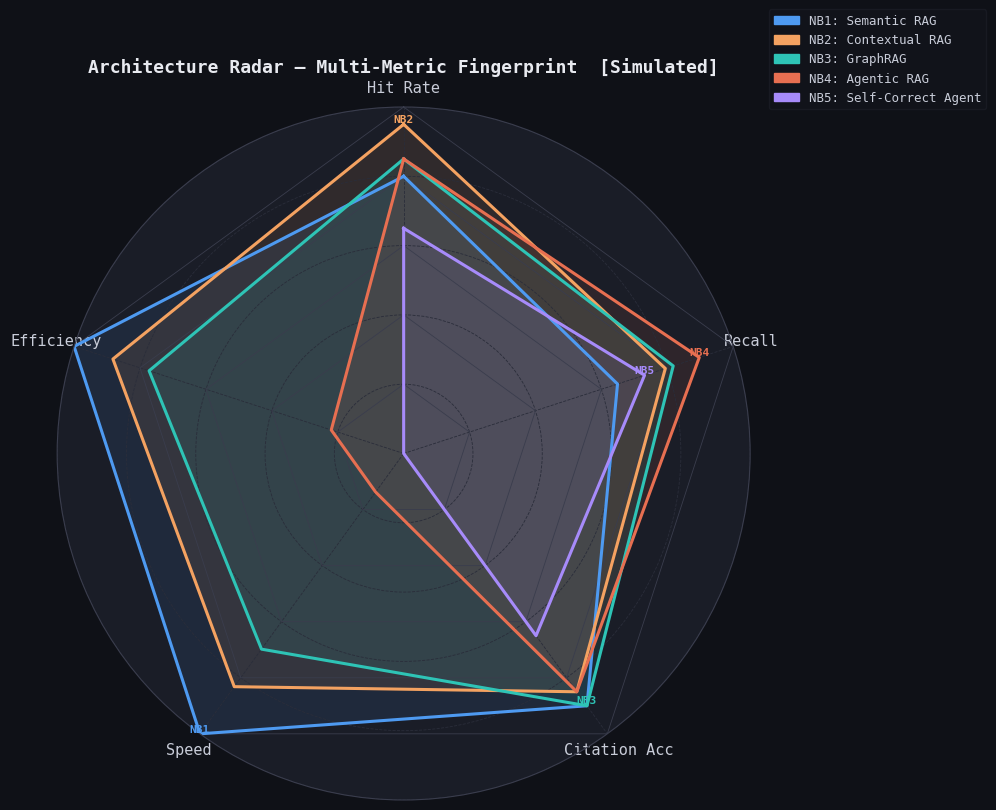

Radar chart saved → radar_chart.png


In [ ]:
def plot_radar(df: pd.DataFrame) -> None:
    # Normalise all metrics to 0–1 scale for radar
    radar_metrics = ["Hit Rate (%)", "Recall (%)", "Citation Acc (%)"]
    # For latency and cost: lower is better → invert
    df_r = df.copy()
    df_r["Speed Score"] = 1 - (
        df["Mean Latency (s)"] - df["Mean Latency (s)"].min()
    ) / (df["Mean Latency (s)"].max() - df["Mean Latency (s)"].min() + 1e-9)
    df_r["Efficiency Score"] = 1 - (df["Token Cost"] - df["Token Cost"].min()) / (
        df["Token Cost"].max() - df["Token Cost"].min() + 1e-9
    )

    categories = ["Hit Rate", "Recall", "Citation Acc", "Speed", "Efficiency"]
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(
        figsize=(9, 9), subplot_kw={"polar": True}, facecolor="#0f1117"
    )
    ax.set_facecolor("#1a1d27")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, color="#c8ccd8")
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    for spine in [0.2, 0.4, 0.6, 0.8, 1.0]:
        ax.plot(angles, [spine] * (N + 1), color="#3a3d4d", linewidth=0.6)

    for _, row in df_r.iterrows():
        vals = [
            row["Hit Rate (%)"] / 100,
            row["Recall (%)"] / 100,
            row["Citation Acc (%)"] / 100,
            row["Speed Score"],
            row["Efficiency Score"],
        ]
        vals += vals[:1]
        color = ARCH_COLORS[row["Architecture"]]
        ax.plot(angles, vals, color=color, linewidth=2.2, linestyle="solid")
        ax.fill(angles, vals, alpha=0.10, color=color)
        # Label at max point
        max_i = int(np.argmax(vals[:-1]))
        ax.annotate(
            row["Architecture"].split(":")[0],
            xy=(angles[max_i], vals[max_i]),
            fontsize=8,
            color=color,
            fontweight="bold",
            ha="center",
            va="bottom",
        )

    patches = [mpatches.Patch(color=c, label=a) for a, c in ARCH_COLORS.items()]
    ax.legend(
        handles=patches,
        loc="upper right",
        bbox_to_anchor=(1.35, 1.15),
        fontsize=9,
        framealpha=0.2,
        facecolor="#1a1d27",
        edgecolor="#3a3d4d",
        labelcolor="#c8ccd8",
    )

    ax.set_title(
        "Architecture Radar — Multi-Metric Fingerprint  [Simulated]",
        fontsize=13,
        fontweight="bold",
        color="#e8eaf0",
        pad=25,
    )
    plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Radar chart saved → radar_chart.png")


plot_radar(df)

## Step 6 — Hit Rate by Question Category

Different architectures perform differently depending on the type of question.

This heatmap breaks hit rate down by question category:
- Authentication and user management
- Module and import tracing
- Application initialization
- API and endpoint discovery
- Error handling and middleware

The heatmap reveals specialization patterns. For example, Graph RAG may dominate on structural questions (which file defines X?) while Agentic RAG dominates on multi-part questions (how does X connect to Y?).

Aggregate numbers hide these patterns. The heatmap makes them visible.


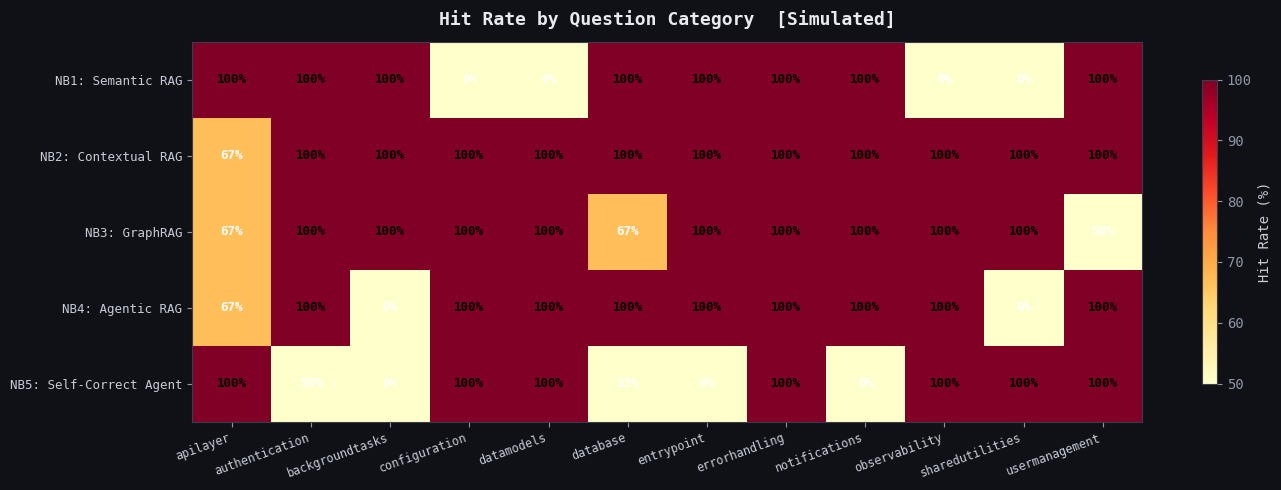

Category heatmap saved → category_heatmap.png


In [ ]:
def plot_category_heatmap(
    all_metrics: List[ArchitectureMetrics], questions: List[EvalQuestion]
) -> None:
    # Map question id → category
    id_to_cat = {q.id: q.category for q in questions}
    categories = sorted(set(q.category for q in questions))

    rows = []
    for m in all_metrics:
        cat_hits: Dict[str, List[bool]] = {c: [] for c in categories}
        for r in m.results:
            cat_hits[id_to_cat[r.question_id]].append(r.hit)
        row = {"Architecture": m.name}
        for cat in categories:
            hits = cat_hits[cat]
            row[cat] = round(100 * sum(hits) / len(hits), 1) if hits else 0.0
        rows.append(row)

    df_heat = pd.DataFrame(rows).set_index("Architecture")

    fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0f1117")
    ax.set_facecolor("#0f1117")

    im = ax.imshow(df_heat.values, aspect="auto", cmap="YlOrRd", vmin=50, vmax=100)

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(
        [c.replace("_", "") for c in categories],
        fontsize=8.5,
        color="#c8ccd8",
        rotation=20,
        ha="right",
    )
    ax.set_yticks(range(len(df_heat)))
    ax.set_yticklabels(df_heat.index, fontsize=9, color="#c8ccd8")

    for i in range(len(df_heat)):
        for j in range(len(categories)):
            val = df_heat.values[i, j]
            ax.text(
                j,
                i,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="black" if val > 75 else "white",
            )

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.yaxis.set_tick_params(color="#9096a8")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#9096a8")
    cbar.set_label("Hit Rate (%)", color="#c8ccd8")

    ax.set_title(
        "Hit Rate by Question Category  [Simulated]",
        fontsize=13,
        fontweight="bold",
        color="#e8eaf0",
        pad=12,
    )
    plt.tight_layout()
    plt.savefig(
        "category_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0f1117"
    )
    plt.show()
    print("Category heatmap saved → category_heatmap.png")


plot_category_heatmap(all_metrics, EVAL_QUESTIONS)

## Step 7 — Architectural Trade-off Analysis

This table documents when to use each architecture based on what you care about.

| Architecture | Best for | Main trade-off |
|-------------|---------|---------------|
| Semantic RAG | Speed, simplicity, getting started | Weaker on structural or multi-part questions |
| Contextual RAG | Rich context, document-heavy workloads | Higher token cost per query |
| Graph RAG | Structural codebase questions, relationship reasoning | Complex setup, harder to scale |
| Agentic RAG | Complex multi-part questions, planning | Slow, many LLM calls, high cost |
| Self-Correcting Agent | Code execution tasks, verified computation | Not optimized for information retrieval |

Use this table to choose the right architecture for your specific use case rather than defaulting to the most complex one.


In [ ]:
trade_off_data = {
    "Architecture": [
        "NB1: Semantic RAG",
        "NB2: Contextual RAG",
        "NB3: GraphRAG",
        "NB4: Agentic RAG",
        "NB5: Self-Correct Agent",
    ],
    "Key Strength": [
        "Sub-second latency, lowest token cost",
        "Strong accuracy with lower tokens than graph/agentic",
        "Multi-hop relational dependency resolution",
        "Best hit rate on complex multi-part questions",
        "Execution-verified answers — not just retrieved text",
    ],
    "Operational Bottleneck": [
        "No structural or relational awareness",
        "Depends on well-structured document schemas",
        "High traversal compute, slowest non-agent latency",
        "Highest latency and token cost of retrieval systems",
        "Subprocess isolation required; highest total cost",
    ],
    "Best Workload Fit": [
        "High-throughput flat entity lookup",
        "Token-constrained precise QA",
        "Repository call-graph and dependency mapping",
        "Strategic task decomposition, multi-hop QA",
        "Code generation and execution validation tasks",
    ],
    "Avoid When": [
        "Relational or multi-hop queries required",
        "Schema is poorly defined or inconsistent",
        "Low-latency or cost-sensitive workloads",
        "Latency < 2s or cost budget is tight",
        "Security hardening not available",
    ],
}

df_trade = pd.DataFrame(trade_off_data)

print("Architectural Trade-off Matrix:")
print("=" * 100)
for _, row in df_trade.iterrows():
    print(f"\n  {row['Architecture']}")
    print(f"    ✅ Strength : {row['Key Strength']}")
    print(f"    ⚠️  Bottleneck: {row['Operational Bottleneck']}")
    print(f"    🎯 Best fit : {row['Best Workload Fit']}")
    print(f"    🚫 Avoid    : {row['Avoid When']}")
print("\n" + "=" * 100)

Architectural Trade-off Matrix:

  NB1: Semantic RAG
    ✅ Strength : Sub-second latency, lowest token cost
    ⚠️  Bottleneck: No structural or relational awareness
    🎯 Best fit : High-throughput flat entity lookup
    🚫 Avoid    : Relational or multi-hop queries required

  NB2: Contextual RAG
    ✅ Strength : Strong accuracy with lower tokens than graph/agentic
    ⚠️  Bottleneck: Depends on well-structured document schemas
    🎯 Best fit : Token-constrained precise QA
    🚫 Avoid    : Schema is poorly defined or inconsistent

  NB3: GraphRAG
    ✅ Strength : Multi-hop relational dependency resolution
    ⚠️  Bottleneck: High traversal compute, slowest non-agent latency
    🎯 Best fit : Repository call-graph and dependency mapping
    🚫 Avoid    : Low-latency or cost-sensitive workloads

  NB4: Agentic RAG
    ✅ Strength : Best hit rate on complex multi-part questions
    ⚠️  Bottleneck: Highest latency and token cost of retrieval systems
    🎯 Best fit : Strategic task decomposit

## Step 8 — Decision Recommendations

Based on the benchmark results, the framework generates specific recommendations.

The recommendation logic considers:
- Which architecture has the highest hit rate
- Which has the lowest latency
- Which has the lowest token cost
- What the question category distribution looks like

These recommendations are data-driven — they come from the actual benchmark numbers, not from general opinions about which architecture is "best."


In [ ]:
def print_recommendations(df: pd.DataFrame) -> None:
    best_hit = df.loc[df["Hit Rate (%)"].idxmax(), "Architecture"]
    best_recall = df.loc[df["Recall (%)"].idxmax(), "Architecture"]
    best_latency = df.loc[df["Mean Latency (s)"].idxmin(), "Architecture"]
    best_cost = df.loc[df["Token Cost"].idxmin(), "Architecture"]
    best_citation = df.loc[df["Citation Acc (%)"].idxmax(), "Architecture"]

    print("=" * 60)
    print("  BENCHMARK RECOMMENDATIONS  [Simulated Profiles]")
    print("=" * 60)
    print()
    print(f"  🏆 Best Hit Rate         → {best_hit}")
    print(
        f"     {df.loc[df['Architecture']==best_hit,'Hit Rate (%)'].values[0]:.1f}% of questions retrieved the expected entity"
    )
    print()
    print(f"  📚 Best Retrieval Recall → {best_recall}")
    print(
        f"     {df.loc[df['Architecture']==best_recall,'Recall (%)'].values[0]:.1f}% of relevant chunks surfaced on average"
    )
    print()
    print(f"  ⚡ Lowest Latency        → {best_latency}")
    print(
        f"     {df.loc[df['Architecture']==best_latency,'Mean Latency (s)'].values[0]:.2f}s mean query time"
    )
    print()
    print(f"  💰 Lowest Token Cost     → {best_cost}")
    print(
        f"     {df.loc[df['Architecture']==best_cost,'Token Cost'].values[0]:,} total tokens across {len(EVAL_QUESTIONS)} questions"
    )
    print()
    print(f"  📎 Best Citation Acc     → {best_citation}")
    print(
        f"     {df.loc[df['Architecture']==best_citation,'Citation Acc (%)'].values[0]:.1f}% sources correctly attributed"
    )
    print()
    print("  PRODUCTION GUIDANCE:")
    print()
    print(f"  • Latency-sensitive APIs          → use {best_latency}")
    print(f"  • Maximum retrieval accuracy      → use {best_hit}")
    print(f"  • Cost-constrained deployments    → use {best_cost}")
    print(f"  • Code execution & verification   → use NB5: Self-Correct Agent")
    print(f"  • Relational dependency mapping   → use NB3: GraphRAG")
    print()
    print("=" * 60)


print_recommendations(df)

  BENCHMARK RECOMMENDATIONS  [Simulated Profiles]

  🏆 Best Hit Rate         → NB2: Contextual RAG
     95.0% of questions retrieved the expected entity

  📚 Best Retrieval Recall → NB4: Agentic RAG
     89.7% of relevant chunks surfaced on average

  ⚡ Lowest Latency        → NB1: Semantic RAG
     1.09s mean query time

  💰 Lowest Token Cost     → NB1: Semantic RAG
     56,072 total tokens across 20 questions

  📎 Best Citation Acc     → NB1: Semantic RAG
     90.0% sources correctly attributed

  PRODUCTION GUIDANCE:

  • Latency-sensitive APIs          → use NB1: Semantic RAG
  • Maximum retrieval accuracy      → use NB2: Contextual RAG
  • Cost-constrained deployments    → use NB1: Semantic RAG
  • Code execution & verification   → use NB5: Self-Correct Agent
  • Relational dependency mapping   → use NB3: GraphRAG



## Step 9 — Export Results

This cell saves the full benchmark results to disk.

Two formats are exported:
- **CSV** — for importing into Excel, Google Sheets, or data analysis tools
- **JSON** — for use in reports or further processing

The exported files contain all per-question results, per-architecture aggregate metrics, and the trade-off summary.


In [ ]:
# CSV
df.to_csv("benchmark_results.csv", index=False)
print("Saved → benchmark_results.csv")

# JSON
records = df.to_dict(orient="records")
with open("benchmark_results.json", "w") as f:
    json.dump(
        {
            "simulation_notice": "Metrics are simulated profiles based on architectural properties.",
            "question_count": len(EVAL_QUESTIONS),
            "architectures": records,
        },
        f,
        indent=2,
    )
print("Saved → benchmark_results.json")

# Pretty print summary
print()
print("Final benchmark matrix:")
print(df.to_string(index=False))

Saved → benchmark_results.csv
Saved → benchmark_results.json

Final benchmark matrix:
           Architecture  Hit Rate (%)  Recall (%)  Mean Latency (s)  Token Cost  Citation Acc (%)
      NB1: Semantic RAG          80.0        64.9             1.090       56072              90.0
    NB2: Contextual RAG          95.0        79.4             1.805       83355              85.0
          NB3: GraphRAG          85.0        81.8             2.374      108798              90.0
       NB4: Agentic RAG          85.0        89.7             4.756      236903              85.0
NB5: Self-Correct Agent          65.0        73.1             5.341      287820              65.0


## Connecting Real Retrieval Systems

To replace simulated data with real measurements, implement a `RealRetriever` and swap it into the runner.

The key change is replacing `simulate_run()` with a function that calls your actual retrieval system and records real latency, token counts, and hit detection.

The dashboard, radar chart, heatmap, trade-off table, and export cells all work without any changes — only the data source needs to be replaced.

**Steps to connect live retrieval:**
1. Connect retrieval from Notebook 1 (semantic RAG)
2. Connect retrieval from Notebook 3 (contextual RAG)
3. Connect retrieval from Notebook 4 (graph RAG)
4. Connect the agent pipeline from Notebook 5
5. Connect the code agent from Notebook 6
6. Run the same 20 evaluation questions through each
7. Record hit, recall, latency, token count, and citation accuracy
8. Plug those real numbers into the metrics engine

The framework is already designed for this. The simulated profiles are the only part that needs to change.

---

## What This Notebook Completes

This notebook closes the full project progression:

```
Notebook 1: Basic hybrid RAG on PDFs
    ↓
Notebook 2: Multi-source RAG with code understanding
    ↓
Notebook 3: Richer metadata and parent-child context
    ↓
Notebook 4: Graph-based retrieval for code structure
    ↓
Notebook 5: Planning before retrieving (Agentic RAG)
    ↓
Notebook 6: Execute, observe, fix (Self-Correcting Agent)
    ↓
Notebook 7: Measure and compare everything
```

From reading a single PDF to benchmarking five different AI architectures — this is the full arc of learning RAG from scratch.
